In [1]:
packages <- c("ggplot2", "dplyr", "tidyr")
for (pkg in packages) {
    suppressMessages(
        suppressWarnings(
            library(pkg, character.only = TRUE)
    )   )
}

In [2]:
feature_importances_df = arrow::read_parquet(
    file.path("../model_results/combined_feature_importances.parquet"))
model_performance_df = arrow::read_parquet(file.path("../model_results/combined_model_performance.parquet"))
predicted_viabilities_df = arrow::read_parquet(file.path("../model_results/combined_predicted_viabilities.parquet"))
summary_metrics_df = arrow::read_parquet(file.path("../model_results/combined_summary_metrics.parquet"))

ERROR: Error: IOError: Failed to open local file '../model_results/combined_feature_importances.parquet'. Detail: [errno 2] No such file or directory


In [ ]:
head(model_performance_df)

Metadata_fold,Metadata_held_out_group,Metadata_eval_split,Metadata_n_samples,Metadata_split_method,Metadata_shuffle_status,Metadata_profile_type,R2,MSE,MAE,MAPE,RMSE,Metadata_source_file
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0,NF0014_T1,train,21,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,0.8399686,258.0320,10.079902,58.82251,16.06337,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet
0,NF0014_T1,test,3,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,0.6028992,363.1370,13.227461,199.18492,19.05615,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet
1,NF0014_T2,train,21,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,0.8726514,223.0348,8.802175,53.34471,14.93435,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet
1,NF0014_T2,test,3,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,-4.3773012,1685.7271,31.993991,29.49734,41.05761,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet
2,NF0018_T6,train,18,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,0.8477318,293.2281,10.709097,59.58965,17.12390,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet
2,NF0018_T6,test,6,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,0.1692591,721.2420,20.232803,130.10040,26.85595,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet


In [3]:
# plot the model performance metrics for each profile type
mse_plot <- (
    ggplot(model_performance_df, aes(x = Metadata_eval_split, y = MSE)) 
    + geom_boxplot(aes(fill = Metadata_eval_split), alpha = 0.5)
    + facet_grid(Metadata_split_method~Metadata_shuffle_status, scales = "free")
    + theme_bw()

)
mse_plot
r2_plot <- (
    ggplot(model_performance_df, aes(x = Metadata_eval_split, y = R2)) 
    + geom_boxplot(aes(fill = Metadata_eval_split), alpha = 0.5)
    + facet_grid(Metadata_split_method~Metadata_shuffle_status, scales = "free")
    + theme_bw()
)
r2_plot

ERROR: Error in ggplot(model_performance_df, aes(x = Metadata_eval_split, y = MSE)): object 'model_performance_df' not found


In [ ]:
head(feature_importances_df)
feature_importances_df$importance_abs <- abs(feature_importances_df$importance)
# get the top 2 features by absolute importance for each profile type
top_features_df <- feature_importances_df %>%
    group_by(Metadata_profile_type) %>%
    top_n(2, importance_abs) %>%
    ungroup() %>%
    arrange(Metadata_profile_type, desc(importance_abs))

feature,importance,Metadata_fold,Metadata_held_out_group,Metadata_split_method,Metadata_shuffle_status,Metadata_profile_type,Metadata_source_file,importance_abs
<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
Nucleocentric_AGP_CHAMMI75_Feature0,0,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,0
Nucleocentric_AGP_CHAMMI75_Feature1,0,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,0
Nucleocentric_AGP_CHAMMI75_Feature10,0,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,0
Nucleocentric_AGP_CHAMMI75_Feature100,0,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,0
Nucleocentric_AGP_CHAMMI75_Feature101,0,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,0
Nucleocentric_AGP_CHAMMI75_Feature102,0,0,NF0014_T1,lopo,not_shuffled,nucleocentric_morphem_norm_sc_consensus_profiles,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,0


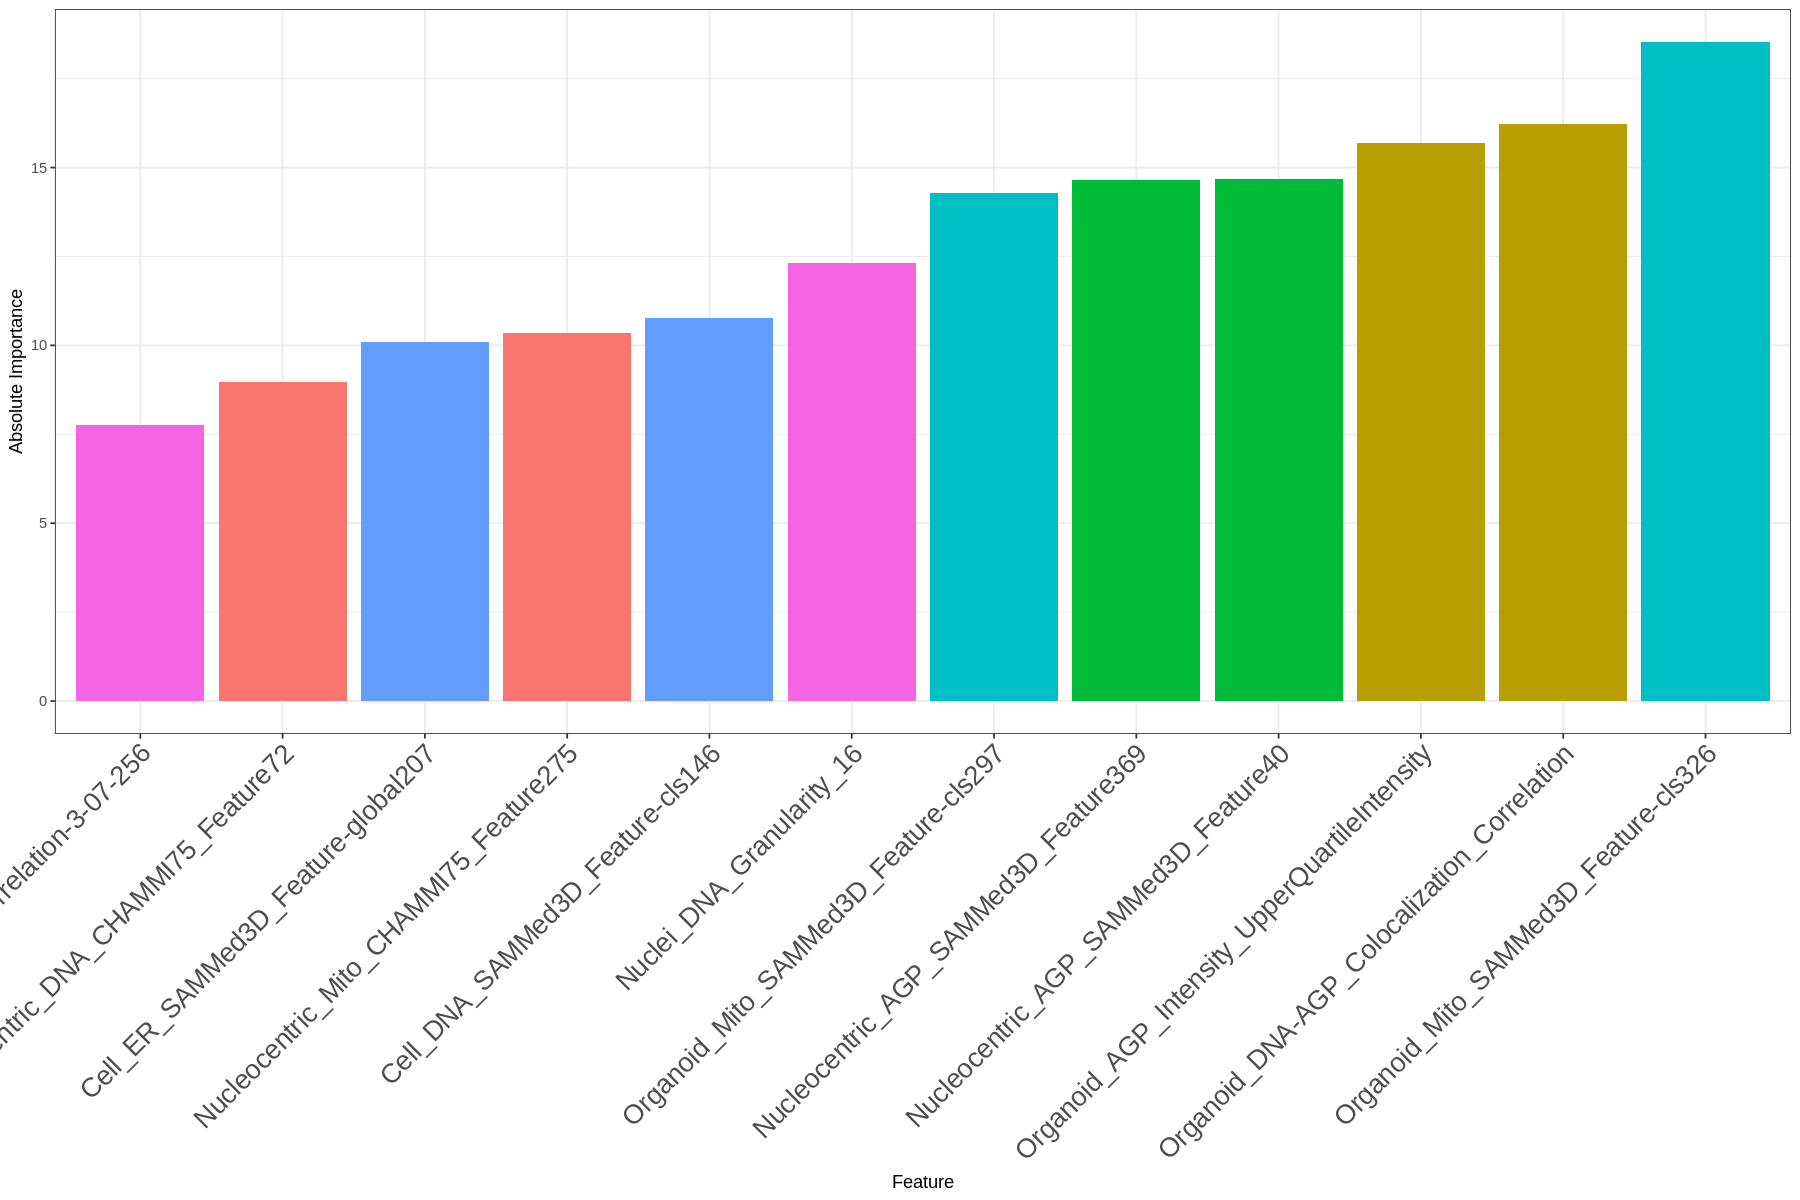

In [ ]:
height <- 10
width <- 15
options(repr.plot.width = width, repr.plot.height = height)
feature_importances_plot <- (
    ggplot(top_features_df, aes(x = reorder(feature, importance_abs), y = importance_abs, fill = Metadata_profile_type))
    + geom_bar(stat = "identity", position = "dodge")
    # + facet_wrap(~Metadata_profile_type, scales = "free_y")
    + theme_bw()
    + labs(x = "Feature", y = "Absolute Importance")
    + theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 16))
    + theme(legend.position = "none")
)
feature_importances_plot

In [ ]:
head(predicted_viabilities_df)

In [ ]:
head(predicted_viabilities_df)

Metadata_Biology_PatientTumor,Metadata_Experiment_Treatment,Metadata_Experiment_Dose,Metadata_Experiment_Class,Metadata_Experiment_Target,Metadata_Experiment_TherapeuticCategories,Metadata_Experiment_Unit,Nucleocentric_AGP_CHAMMI75_Feature0,Nucleocentric_AGP_CHAMMI75_Feature1,Nucleocentric_AGP_CHAMMI75_Feature10,⋯,Nuclei_Mito_Texture_Variance-3-08-256,Nuclei_Mito_Texture_Variance-3-09-256,Nuclei_Mito_Texture_Variance-3-10-256,Nuclei_Mito_Texture_Variance-3-11-256,Nuclei_Mito_Texture_Variance-3-12-256,Nuclei_NoChannel_AreaSizeShape_BboxVolume,Nuclei_NoChannel_AreaSizeShape_EulerNumber,Nuclei_NoChannel_AreaSizeShape_Extent,Nuclei_NoChannel_AreaSizeShape_SurfaceArea,Nuclei_NoChannel_AreaSizeShape_Volume
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NF0014_T1,Staurosporine,10,Small Molecule,Apoptosis induction,Experimental,nM,-0.57977382,-0.8857537,-0.4898659,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NF0014_T1,Linsitinib,1,Small Molecule,IGF-1R inhibitor,Investigational,uM,-0.11883289,-0.2724531,-0.2829768,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NF0014_T1,Copanlisib,1,Small Molecule,PI3K inhibitor,Kinase Inhibitor,uM,-0.26590697,-0.9607741,-0.3641385,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NF0014_T2,Mirdametinib,1,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,uM,0.32791192,-0.1712172,0.2048557,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NF0014_T2,Selumetinib,10,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,uM,-0.08839382,-0.3490350,0.2739686,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NF0014_T2,DMSO,1,Control,Control,Control,%,0.00000000,0.0000000,0.0000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


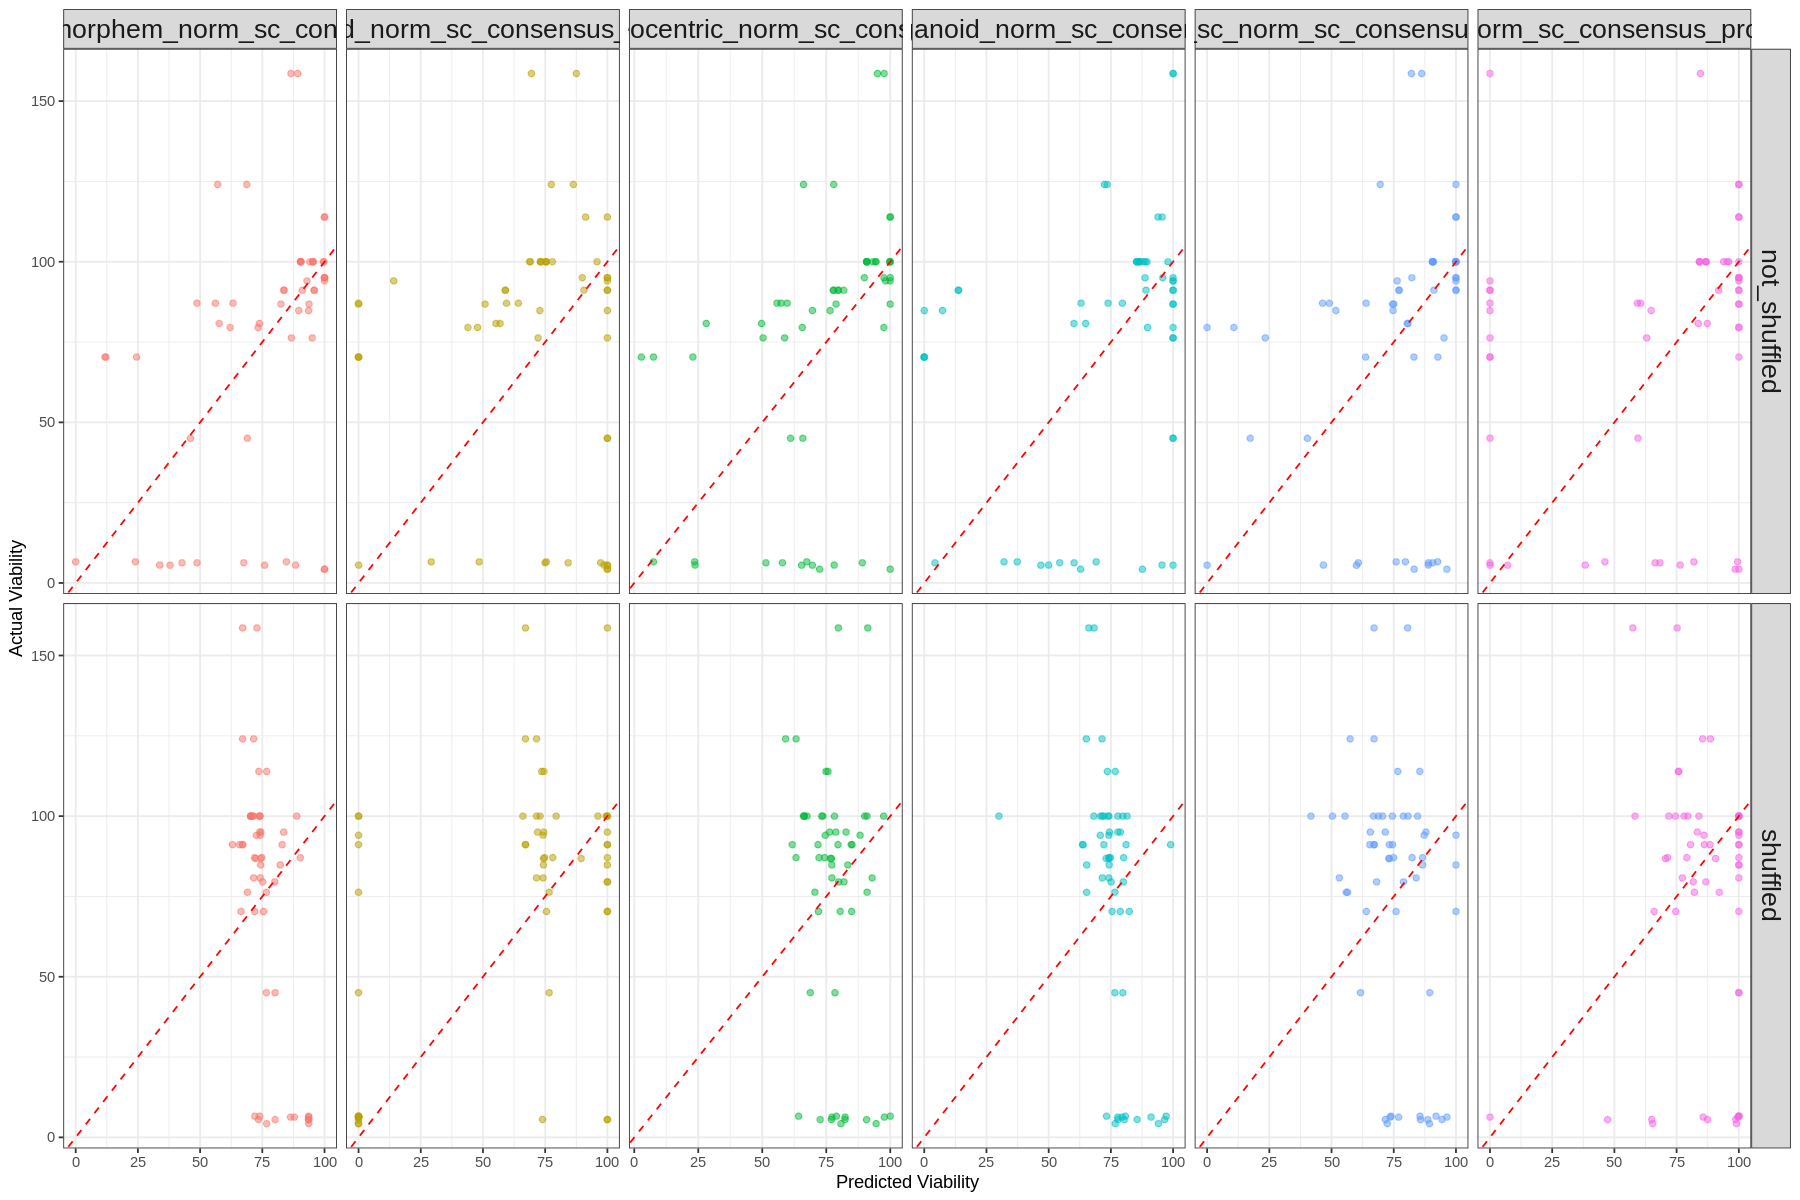

In [ ]:
# predicted viabilities plot
predicted_viabilities_plot <- (
    ggplot(predicted_viabilities_df, aes(x = Predicted_Viability, y = Actual_Viability, color = Metadata_profile_type))
    + geom_point(alpha = 0.5)
    + geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red")
    + facet_grid(Metadata_shuffle_status~Metadata_profile_type, scales = "free")
    + theme_bw()
    + labs(x = "Predicted Viability", y = "Actual Viability")
    + theme(legend.position = "none")
    # make the strip text larger
    + theme(strip.text = element_text(size = 16))
)   
predicted_viabilities_plot